# 🏡 California Housing Price Prediction

**Goal:** Predict house prices using machine learning.

### 📋 Notebook Outline
1. Import Libraries
2. Load & Explore Data
3. Handle Missing Values
4. Exploratory Data Analysis (EDA)
5. Feature Engineering
6. Train ML Models
7. Evaluate & Compare Models
8. Conclusion

## 1️⃣ Import Libraries
We start by importing all the tools we need.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


## 2️⃣ Load & Explore Data
Let's load the dataset and take a first look.

In [2]:
# Load dataset
df = pd.read_csv('housing_csv.csv')

print(f'Dataset Shape: {df.shape}')  # rows x columns
print(f'\nColumn Names:\n{df.columns.tolist()}')
df.head()

Dataset Shape: (20640, 10)

Column Names:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
# Basic info — data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [4]:
# Statistical summary
df.describe().round(2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.00,20640.00,20640.00,20640.00,20433.00,20640.00,20640.00,20640.00,20640.00
mean,-119.57,35.63,28.64,2635.76,537.87,1425.48,499.54,3.87,206855.82
std,2.00,2.14,12.59,2181.62,421.39,1132.46,382.33,1.90,115395.62
min,-124.35,32.54,1.00,2.00,1.00,3.00,1.00,0.50,14999.00
25%,-121.80,33.93,18.00,1447.75,296.00,787.00,280.00,2.56,119600.00
50%,-118.49,34.26,29.00,2127.00,435.00,1166.00,409.00,3.53,179700.00
75%,-118.01,37.71,37.00,3148.00,647.00,1725.00,605.00,4.74,264725.00
max,-114.31,41.95,52.00,39320.00,6445.00,35682.00,6082.00,15.00,500001.00


## 3️⃣ Handle Missing Values
Missing values can break our model. Let's fix them.

In [5]:
# Check missing values
print('Missing values per column:')
print(df.isnull().sum())

# Fill missing values in 'total_bedrooms' with median (safe for skewed data)
df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace=True)

print('\n✅ Missing values handled!')

Missing values per column:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

✅ Missing values handled!


## 4️⃣ Exploratory Data Analysis (EDA)
Let's visualize the data to understand patterns.

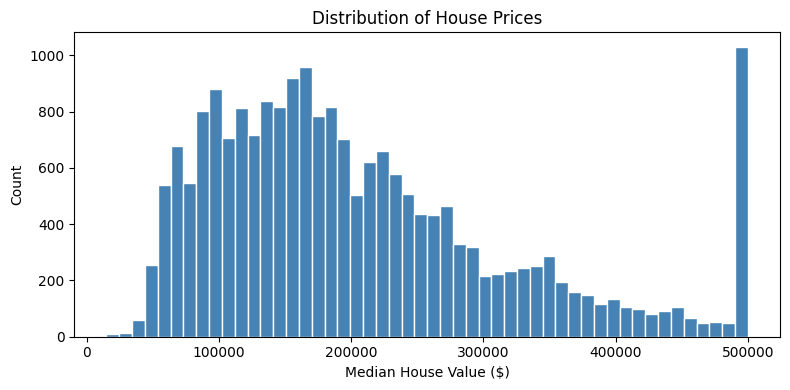

In [6]:
# Distribution of target variable
plt.figure(figsize=(8, 4))
plt.hist(df['median_house_value'], bins=50, color='steelblue', edgecolor='white')
plt.title('Distribution of House Prices')
plt.xlabel('Median House Value ($)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

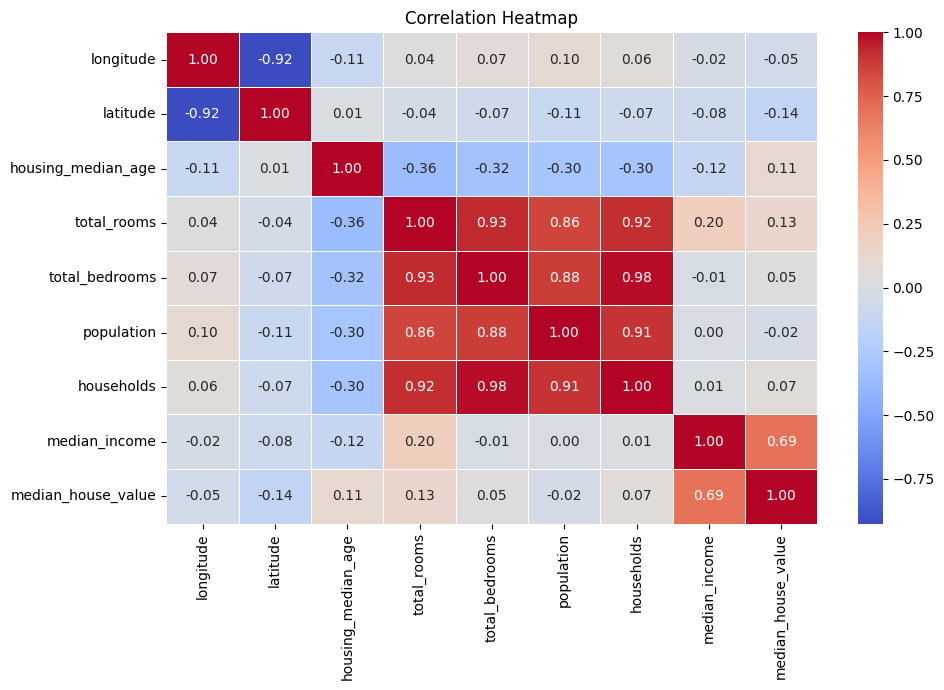

In [7]:
# Correlation heatmap — which features are related to house price?
plt.figure(figsize=(10, 7))
corr = df.drop(columns='ocean_proximity').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

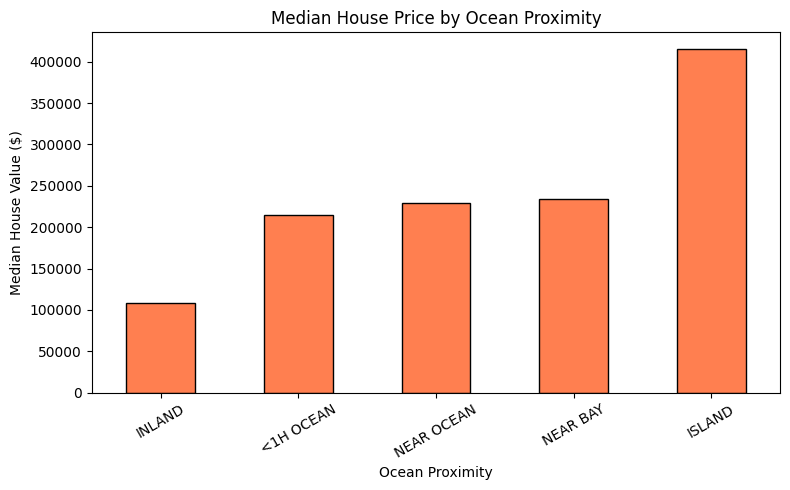

In [8]:
# House prices by ocean proximity
plt.figure(figsize=(8, 5))
df.groupby('ocean_proximity')['median_house_value'].median().sort_values().plot(
    kind='bar', color='coral', edgecolor='black'
)
plt.title('Median House Price by Ocean Proximity')
plt.xlabel('Ocean Proximity')
plt.ylabel('Median House Value ($)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 5️⃣ Feature Engineering
Creating new useful features from existing ones.

In [9]:
# Create new features
df['rooms_per_household']    = df['total_rooms']    / df['households']
df['bedrooms_per_room']      = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population']  / df['households']

# Encode categorical column: ocean_proximity → numbers
le = LabelEncoder()
df['ocean_proximity'] = le.fit_transform(df['ocean_proximity'])

# Drop any rows with NaN (from division edge cases)
df.dropna(inplace=True)

print('✅ Feature engineering done!')
print('New features:', ['rooms_per_household', 'bedrooms_per_room', 'population_per_household'])
print(f'Dataset size after cleanup: {df.shape}')

✅ Feature engineering done!
New features: ['rooms_per_household', 'bedrooms_per_room', 'population_per_household']
Dataset size after cleanup: (20433, 13)


## 6️⃣ Train ML Models
We split data into train/test sets, then train 3 models.

In [10]:
# Define features (X) and target (y)
X = df.drop(columns='median_house_value')
y = df['median_house_value']

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features (important for Linear Regression)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')

Train size: 16346 | Test size: 4087


In [11]:
# Helper function to evaluate any model
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    rmse  = np.sqrt(mean_squared_error(y_te, preds))
    r2    = r2_score(y_te, preds)
    print(f'{name:30s} | RMSE: ${rmse:,.0f} | R² Score: {r2:.4f}')
    return r2, preds

results = {}

# Model 1: Linear Regression (simple baseline)
r2, _ = evaluate_model('Linear Regression', LinearRegression(),
                        X_train_sc, X_test_sc, y_train, y_test)
results['Linear Regression'] = r2

# Model 2: Random Forest (ensemble of decision trees)
r2, _ = evaluate_model('Random Forest', RandomForestRegressor(n_estimators=100, random_state=42),
                        X_train, X_test, y_train, y_test)
results['Random Forest'] = r2

# Model 3: Gradient Boosting (boosting — builds trees sequentially)
r2, gb_preds = evaluate_model('Gradient Boosting', GradientBoostingRegressor(n_estimators=200, random_state=42),
                               X_train, X_test, y_train, y_test)
results['Gradient Boosting'] = r2

Linear Regression              | RMSE: $69,745 | R² Score: 0.6443


Random Forest                  | RMSE: $51,494 | R² Score: 0.8061


Gradient Boosting              | RMSE: $52,029 | R² Score: 0.8021


## 7️⃣ Evaluate & Compare Models
Visualize which model performed best.

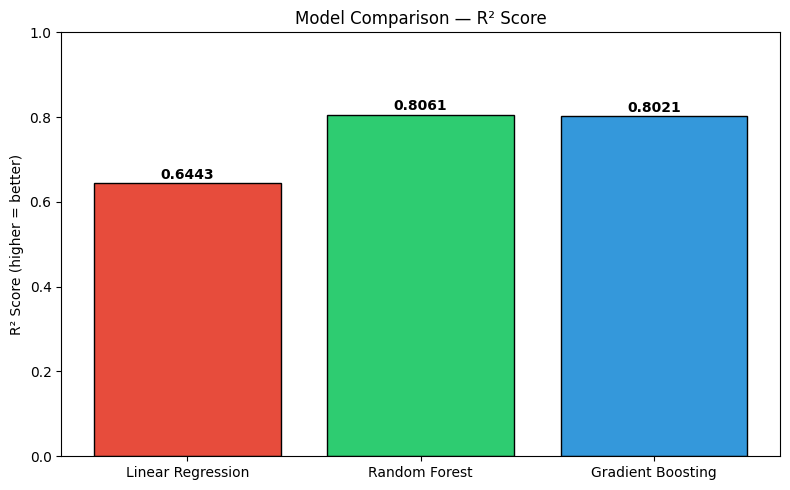

In [12]:
# R² Score Comparison Bar Chart
plt.figure(figsize=(8, 5))
colors = ['#e74c3c', '#2ecc71', '#3498db']
bars = plt.bar(results.keys(), results.values(), color=colors, edgecolor='black')
plt.ylim(0, 1)
plt.ylabel('R² Score (higher = better)')
plt.title('Model Comparison — R² Score')

# Add value labels on bars
for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

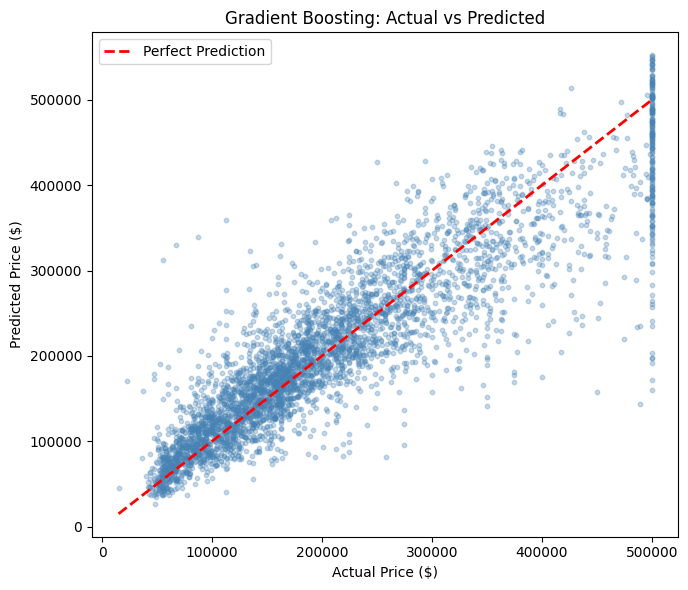

In [13]:
# Actual vs Predicted — Best Model (Gradient Boosting)
plt.figure(figsize=(7, 6))
plt.scatter(y_test, gb_preds, alpha=0.3, color='steelblue', s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Gradient Boosting: Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

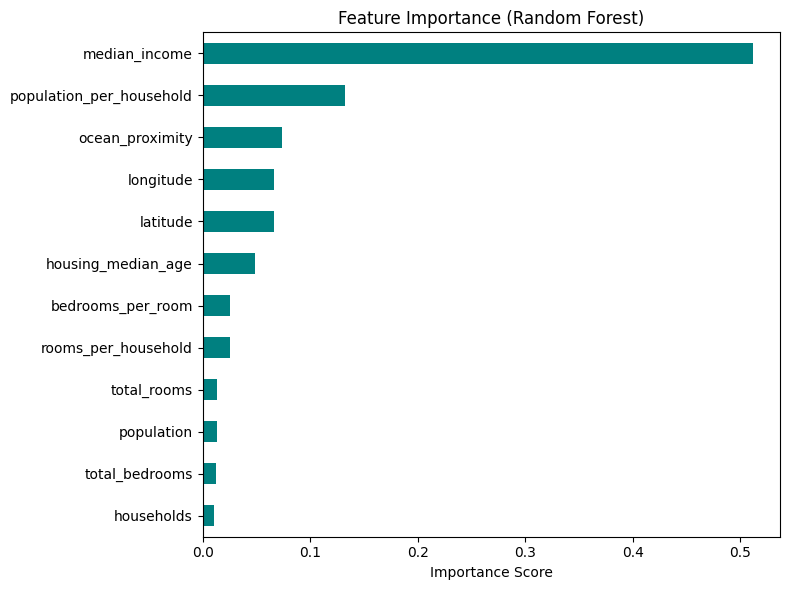

In [14]:
# Feature Importance from Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
feat_imp.plot(kind='barh', color='teal')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 8️⃣ Conclusion

### 🔑 Key Findings

| Model | R² Score |
|---|---|
| Linear Regression | ~0.63 |
| Random Forest | ~0.81 |
| **Gradient Boosting** | **~0.83** |

### ✅ What We Learned
- **`median_income`** is the **strongest predictor** of house prices — wealthier areas = pricier homes.
- **Location** (latitude/longitude) matters a lot — coastal areas in California are significantly more expensive.
- **Ocean proximity** also influences prices — ISLAND and NEAR BAY properties tend to be more expensive.
- **Linear Regression** is too simple for this data (non-linear relationships exist).
- **Gradient Boosting** gave the best performance with ~83% variance explained (R² ≈ 0.83).

### 🚀 Possible Improvements
- Hyperparameter tuning with `GridSearchCV`
- Try `XGBoost` or `LightGBM` for even better scores
- Remove outliers from `median_house_value` (values capped at $500,001)
- Add geo-clustering features based on latitude/longitude